# 03: LinearDML and SparseLinearDML

We focus on two closely related EconML estimators:

- `LinearDML`, which estimates a linear CATE model over chosen effect modifiers;
- `SparseLinearDML`, which is designed for wider effect-modifier spaces where only some features are expected to matter.

The teaching question is:

> Which pre-treatment features appear to change the size of the treatment effect, and can we estimate those effect drivers after adjusting for confounding?

This is the first estimator-specific lesson in the EconML tutorial sequence. The previous lesson built DML from scratch. Here we lean into the library API and focus on practical modeling decisions: feature roles, coefficient reading, sparse selection behavior, CATE recovery, and treatment targeting.


## Learning Goals

By the end, you should be able to:

- fit `LinearDML` with observed confounders and effect modifiers;
- fit `SparseLinearDML` on a wider set of candidate effect modifiers;
- explain the difference between nuisance models and the final CATE model;
- read final-stage CATE coefficients without confusing them for outcome-model coefficients;
- compare dense and sparse CATE estimates against known truth in a simulation;
- diagnose coefficient stability, noise-feature shrinkage, CATE ranking quality, and segment-level recovery;
- decide when a linear CATE model is a reasonable first estimator.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **LinearDML And SparseLinearDML**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment uses linear final-stage structure to make CATE interpretation transparent while still allowing flexible nuisance learning. The experiment uses sparse effect modification to show how regularization can help when many candidate modifiers are available.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

Double machine learning estimates treatment effects after removing predictable parts of outcome and treatment. A partially linear CATE model can be written as

$$
Y=\theta(X)D+g_0(X)+\varepsilon.
$$

For a constant effect, the final stage is

$$
Y-\widehat g(X) \approx \theta\{D-\widehat m(X)\}.
$$

LinearDML, SparseLinearDML, and CausalForestDML differ in how they represent $\theta(X)$.


## Why LinearDML Comes First

`LinearDML` is often the easiest serious EconML estimator to explain. It combines two useful properties:

- flexible nuisance models can estimate the baseline outcome and treatment assignment process;
- the final treatment-effect model remains linear and readable.

That means the model can adjust for confounding with machine learning while still producing coefficient-style CATE drivers. For example, a positive coefficient on `baseline_need` means the estimated treatment effect is larger for higher values of `baseline_need`, after the DML adjustment process.

`SparseLinearDML` keeps the same broad structure but adds sparse regularization in the final CATE stage. That is useful when we have many possible effect modifiers and want the final model to concentrate on the strongest signals.





## Tutorial Workflow

#### LinearDML versus SparseLinearDML

The next table summarizes how to think about the two estimators before writing code.


In [ ]:
# Build and label the diagnostic visualization for the LinearDML Versus SparseLinearDML section.
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata
# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
import numpy as np
# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default
    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split
try:
    import econml
    from econml.dml import LinearDML, SparseLinearDML
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
estimator_map = pd.DataFrame(
    [
        {
            "estimator": "LinearDML",
            "final CATE model": "Dense linear model over X",
            "best first use": "A moderate number of meaningful effect modifiers",
            "main strength": "Readable coefficient-style effect drivers",
            "main risk": "Can assign visible coefficients to weak or noisy modifiers",
        },
        {
            "estimator": "SparseLinearDML",
            "final CATE model": "Sparse regularized linear model over X",
            "best first use": "A wider candidate feature set with only some true effect drivers",
            "main strength": "Shrinks weak CATE drivers and can highlight a smaller feature set",
            "main risk": "Regularization can shrink real but subtle signals too much",
        },
    ]
)
estimator_map.to_csv(TABLE_DIR / "03_estimator_map.csv", index=False)
print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
display(estimator_map)


Both estimators use DML, but they differ in the final CATE stage. The nuisance models handle adjustment; the final stage decides how treatment-effect heterogeneity is represented.


### Data-Generating Design

The synthetic dataset below is designed to teach a specific modeling problem:

- treatment is confounded by observed pre-treatment features;
- the outcome has a flexible baseline component;
- the true treatment effect is sparse and linear in a subset of candidate effect modifiers;
- several noise features are included as tempting but irrelevant effect modifiers.

This gives `LinearDML` and `SparseLinearDML` something meaningful to compare. A dense linear model can estimate every candidate coefficient, while a sparse model should concentrate more of the final-stage weight on the real effect drivers.


In [2]:
# Prepare intermediate objects for the Data-Generating Design section.
n = 3_200
baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = 0.55 * baseline_need - 0.25 * prior_engagement + rng.normal(0, 0.85, size=n)
price_sensitivity = rng.normal(0, 1, size=n)
trust_score = rng.normal(0, 1, size=n)
content_affinity = 0.35 * prior_engagement + rng.normal(0, 0.95, size=n)
recency_gap = rng.normal(0, 1, size=n)
region_risk = rng.binomial(1, 0.34, size=n)
high_need_segment = (baseline_need > 0.55).astype(int)
account_tenure = rng.normal(0, 1, size=n)
seasonality_index = rng.normal(0, 1, size=n)
device_stability = rng.normal(0, 1, size=n)
noise_features = {
    f"noise_modifier_{i:02d}": rng.normal(0, 1, size=n)
    for i in range(1, 13)
}
propensity_logit = (
    -0.15
    + 0.75 * baseline_need
    + 0.45 * prior_engagement
    + 0.35 * friction_score
    + 0.30 * content_affinity
    - 0.25 * trust_score
    + 0.25 * region_risk
    + 0.20 * high_need_segment
    - 0.35 * account_tenure
    + 0.25 * seasonality_index
    + 0.20 * noise_features["noise_modifier_01"]
)
propensity = 1 / (1 + np.exp(-propensity_logit))
propensity = np.clip(propensity, 0.03, 0.97)
treatment = rng.binomial(1, propensity, size=n)
true_cate = (
    0.42
    + 0.30 * baseline_need
    + 0.22 * prior_engagement
    - 0.24 * friction_score
    - 0.18 * price_sensitivity
    + 0.16 * content_affinity
    - 0.12 * region_risk
    + 0.24 * high_need_segment
)
baseline_outcome = (
    2.20
    + 0.80 * baseline_need
    + 0.55 * prior_engagement
    - 0.50 * friction_score
    + 0.30 * trust_score
    + 0.35 * account_tenure
    + 0.25 * seasonality_index
    + 0.20 * device_stability
    + 0.18 * region_risk
    + 0.12 * baseline_need * friction_score
    - 0.10 * price_sensitivity * trust_score
)
noise = rng.normal(0, 0.90, size=n)
outcome = baseline_outcome + true_cate * treatment + noise
teaching_df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "price_sensitivity": price_sensitivity,
        "trust_score": trust_score,
        "content_affinity": content_affinity,
        "recency_gap": recency_gap,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "account_tenure": account_tenure,
        "seasonality_index": seasonality_index,
        "device_stability": device_stability,
        **noise_features,
        "propensity": propensity,
        "treatment": treatment,
        "outcome": outcome,
        "true_cate": true_cate,
        "baseline_outcome_mean": baseline_outcome,
    }
)
teaching_df.head()


,user_id,baseline_need,prior_engagement,friction_score,price_sensitivity,trust_score,content_affinity,recency_gap,region_risk,high_need_segment,account_tenure,seasonality_index,device_stability,noise_modifier_01,noise_modifier_02,noise_modifier_03,noise_modifier_04,noise_modifier_05,noise_modifier_06,noise_modifier_07,noise_modifier_08,noise_modifier_09,noise_modifier_10,noise_modifier_11,noise_modifier_12,propensity,treatment,outcome,true_cate,baseline_outcome_mean
0,0,-0.7931,-1.2901,-0.3725,0.3794,-1.1530,-1.7022,-0.7477,1,0,-3.0473,-0.3020,-0.9402,2.2139,3.3326,1.0087,-0.0561,0.3949,0.2200,-0.2702,0.4688,1.5857,0.6316,0.5724,0.0884,0.5014,0,-0.3295,-0.4730,-0.3746
1,1,0.2406,0.2599,-0.4635,0.2294,-0.9692,1.3488,-0.4711,0,0,-0.5008,-0.4229,1.2210,0.6131,-0.6644,-1.3256,1.2507,0.0068,-1.3397,0.8011,-0.6055,0.2176,-0.8961,-1.7315,-0.4224,0.6951,1,4.1711,0.8351,2.4484
2,2,-1.8963,-0.3197,-0.9924,-0.0940,-1.2255,-0.5499,0.0474,0,0,-0.0048,-0.8700,-1.7494,-0.0209,-0.1113,-1.2531,-0.7628,-0.7286,0.1870,-0.2217,-0.6922,0.9850,-0.3564,1.8125,0.7178,0.1051,0,0.9768,-0.0521,0.2809
3,3,1.3958,-0.2729,0.3750,0.5754,0.6809,-1.5469,1.4382,0,1,1.0852,-0.2230,-2.3089,0.9227,-0.0710,-1.1789,-1.0234,-1.0542,1.8849,-0.0726,-0.6707,-0.7611,-0.5606,0.2016,-1.8027,0.5548,0,5.7941,0.5776,3.0692
4,4,0.6383,-1.4263,0.6936,-1.5145,0.5773,0.6027,2.8067,0,1,-1.8344,-0.9164,-0.2073,-0.3209,-0.6215,-0.9096,-0.5394,-0.7578,0.0065,0.2065,1.3599,0.1552,-0.9609,1.6112,-0.3389,0.6260,0,3.0364,0.7403,0.9805


The table has both real modeling fields and oracle fields. In the model-fitting steps we will use only pre-treatment observed features, treatment, and outcome. `true_cate`, `propensity`, and `baseline_outcome_mean` are kept only for simulation checks.


#### Field Dictionary

A field dictionary is especially useful in estimator tutorials because it separates three ideas that are easy to mix up:

- features used to explain treatment-effect heterogeneity;
- controls used to remove confounding;
- oracle fields available only because this is a simulation.


In [3]:
signal_modifier_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "price_sensitivity",
    "content_affinity",
    "region_risk",
    "high_need_segment",
]
weak_or_null_modifier_cols = ["trust_score", "recency_gap"] + list(noise_features.keys())
effect_modifier_cols = signal_modifier_cols + weak_or_null_modifier_cols
control_cols = ["account_tenure", "seasonality_index", "device_stability"]
all_observed_covariates = effect_modifier_cols + control_cols
field_rows = []
for col in effect_modifier_cols:
    field_rows.append(
        {
            "column": col,
            "model_role": "X candidate effect modifier",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature allowed to modify the treatment effect.",
            "true_cate_driver": "yes" if col in signal_modifier_cols else "no",
        }
    )
for col in control_cols:
    field_rows.append(
        {
            "column": col,
            "model_role": "W control",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature used for adjustment but not used for CATE reporting.",
            "true_cate_driver": "no",
        }
    )
for col, role, description in [
    ("treatment", "treatment", "Binary intervention indicator."),
    ("outcome", "outcome", "Observed post-treatment outcome."),
    ("propensity", "oracle", "True treatment probability from the simulated assignment process."),
    ("true_cate", "oracle", "Known individual treatment effect used for tutorial grading."),
    ("baseline_outcome_mean", "oracle", "Mean untreated outcome component before random noise."),
]:
    field_rows.append(
        {
            "column": col,
            "model_role": role,
            "observed_in_real_analysis": "yes" if role in ["treatment", "outcome"] else "no",
            "description": description,
            "true_cate_driver": "not applicable",
        }
    )
field_dictionary = pd.DataFrame(field_rows)
field_dictionary.to_csv(TABLE_DIR / "03_field_dictionary.csv", index=False)
display(field_dictionary.head(30))


,column,model_role,observed_in_real_analysis,description,true_cate_driver
0,baseline_need,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,yes
1,prior_engagement,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,yes
2,friction_score,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,yes
3,price_sensitivity,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,yes
4,content_affinity,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,yes
5,region_risk,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,yes
6,high_need_segment,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,yes
7,trust_score,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,no
8,recency_gap,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,no
9,noise_modifier_01,X candidate effect modifier,yes,Pre-treatment feature allowed to modify the treatment effect.,no


Some `X` columns are true CATE drivers and others are deliberately irrelevant. That is the point of this lesson: wide candidate effect-modifier sets are common, and sparse final-stage models can help control clutter.


### True CATE Equation

Since this is a simulation, we can show the real treatment-effect equation. The true CATE is sparse: only seven candidate effect modifiers have nonzero coefficients.

In real work, this table is unavailable. We would use domain logic, robustness checks, and validation strategies because ground truth is unavailable.


In [4]:
true_coefficient_map = {
    "cate_intercept": 0.42,
    "baseline_need": 0.30,
    "prior_engagement": 0.22,
    "friction_score": -0.24,
    "price_sensitivity": -0.18,
    "content_affinity": 0.16,
    "region_risk": -0.12,
    "high_need_segment": 0.24,
}
true_coef_table = pd.DataFrame(
    [{"term": "cate_intercept", "true_cate_coefficient": true_coefficient_map["cate_intercept"], "is_true_driver": True}]
    + [
        {
            "term": col,
            "true_cate_coefficient": true_coefficient_map.get(col, 0.0),
            "is_true_driver": col in true_coefficient_map,
        }
        for col in effect_modifier_cols
    ]
)
true_coef_table.to_csv(TABLE_DIR / "03_true_cate_coefficients.csv", index=False)
display(true_coef_table)


,term,true_cate_coefficient,is_true_driver
0,cate_intercept,0.4200,True
1,baseline_need,0.3000,True
2,prior_engagement,0.2200,True
3,friction_score,-0.2400,True
4,price_sensitivity,-0.1800,True
5,content_affinity,0.1600,True
6,region_risk,-0.1200,True
7,high_need_segment,0.2400,True
8,trust_score,0.0000,False
9,recency_gap,0.0000,False


`LinearDML` and `SparseLinearDML` are being asked to estimate this treatment-effect pattern from observational data. The nuisance models must remove confounding first; the final CATE model then tries to recover these coefficients.


#### Basic Shape and True Effects

Before fitting anything, we summarize the sample size, treatment rate, outcome level, and true effect distribution. This establishes the scale of the problem.


In [5]:
basic_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(teaching_df)},
        {"metric": "columns", "value": teaching_df.shape[1]},
        {"metric": "candidate_X_features", "value": len(effect_modifier_cols)},
        {"metric": "W_controls", "value": len(control_cols)},
        {"metric": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"metric": "outcome_mean", "value": teaching_df["outcome"].mean()},
        {"metric": "true_ate", "value": teaching_df["true_cate"].mean()},
        {"metric": "true_cate_std", "value": teaching_df["true_cate"].std()},
        {"metric": "true_cate_min", "value": teaching_df["true_cate"].min()},
        {"metric": "true_cate_max", "value": teaching_df["true_cate"].max()},
    ]
)
basic_summary.to_csv(TABLE_DIR / "03_basic_summary.csv", index=False)
display(basic_summary)


,metric,value
0,rows,"3,200.0000"
1,columns,30.0000
2,candidate_X_features,21.0000
3,W_controls,3.0000
4,treatment_rate,0.4875
5,outcome_mean,2.6234
6,true_ate,0.4614
7,true_cate_std,0.5193
8,true_cate_min,-1.4146
9,true_cate_max,2.0582


The tutorial has enough rows for cross-fitting and enough candidate modifiers to make sparse modeling relevant. The true CATE standard deviation confirms that there is meaningful heterogeneity to estimate.


### Raw Treated-versus-Control Difference

A raw difference in observed outcomes is not a DML estimate. It ignores the treatment assignment process and will usually be biased when treatment is confounded.

The next step compares the raw outcome difference with the true ATE.


In [6]:
raw_group_summary = (
    teaching_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        observed_outcome_mean=("outcome", "mean"),
        true_cate_mean=("true_cate", "mean"),
        propensity_mean=("propensity", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        prior_engagement_mean=("prior_engagement", "mean"),
        friction_score_mean=("friction_score", "mean"),
    )
    .reset_index()
)
raw_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"].eq(1), "observed_outcome_mean"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"].eq(0), "observed_outcome_mean"].iloc[0]
)
true_ate = teaching_df["true_cate"].mean()
raw_difference_summary = pd.DataFrame(
    [
        {"quantity": "raw treated minus untreated outcome mean", "value": raw_difference},
        {"quantity": "true ATE", "value": true_ate},
        {"quantity": "raw difference minus true ATE", "value": raw_difference - true_ate},
    ]
)
raw_group_summary.to_csv(TABLE_DIR / "03_raw_group_summary.csv", index=False)
raw_difference_summary.to_csv(TABLE_DIR / "03_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_summary)


,treatment,rows,observed_outcome_mean,true_cate_mean,propensity_mean,baseline_need_mean,prior_engagement_mean,friction_score_mean
0,0,1640,2.1097,0.3294,0.3731,-0.4104,-0.1270,-0.2990
1,1,1560,3.1635,0.6001,0.6226,0.3651,0.1963,0.2438


,quantity,value
0,raw treated minus untreated outcome mean,1.0538
1,true ATE,0.4614
2,raw difference minus true ATE,0.5924


Treated rows have different baseline covariate profiles and different average true CATE. This is why the estimator needs both nuisance adjustment and a treatment-effect model.





## Diagnostics and Interpretation

#### Covariate Balance Table

The standardized mean difference measures how different treated and untreated groups are before adjustment. Large values are a sign that treatment assignment is strongly related to covariates.


In [7]:
balance_rows = []
for col in all_observed_covariates:
    treated_values = teaching_df.loc[teaching_df["treatment"].eq(1), col]
    control_values = teaching_df.loc[teaching_df["treatment"].eq(0), col]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_difference": (treated_values.mean() - control_values.mean()) / pooled_sd,
        }
    )
balance_table = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=lambda s: s.abs(), ascending=False)
balance_table.to_csv(TABLE_DIR / "03_covariate_balance.csv", index=False)
display(balance_table.head(15))


,covariate,treated_mean,control_mean,standardized_difference
0,baseline_need,0.3651,-0.4104,0.8335
6,high_need_segment,0.4314,0.1506,0.6498
2,friction_score,0.2438,-0.2990,0.5359
1,prior_engagement,0.1963,-0.1270,0.3255
4,content_affinity,0.1886,-0.1187,0.3058
21,account_tenure,-0.1545,0.1409,-0.2953
22,seasonality_index,0.0763,-0.1104,0.1904
7,trust_score,-0.0866,0.0670,-0.1548
9,noise_modifier_01,0.0614,-0.0690,0.1331
5,region_risk,0.3474,0.2963,0.1095


The top imbalance features are exactly the kind of variables that nuisance models need to account for. DML does not erase the need for careful adjustment design; it operationalizes that design with cross-fitted prediction models.


#### Covariate Balance Plot

The plot below focuses on the most imbalanced features so the confounding pattern is easy to scan.


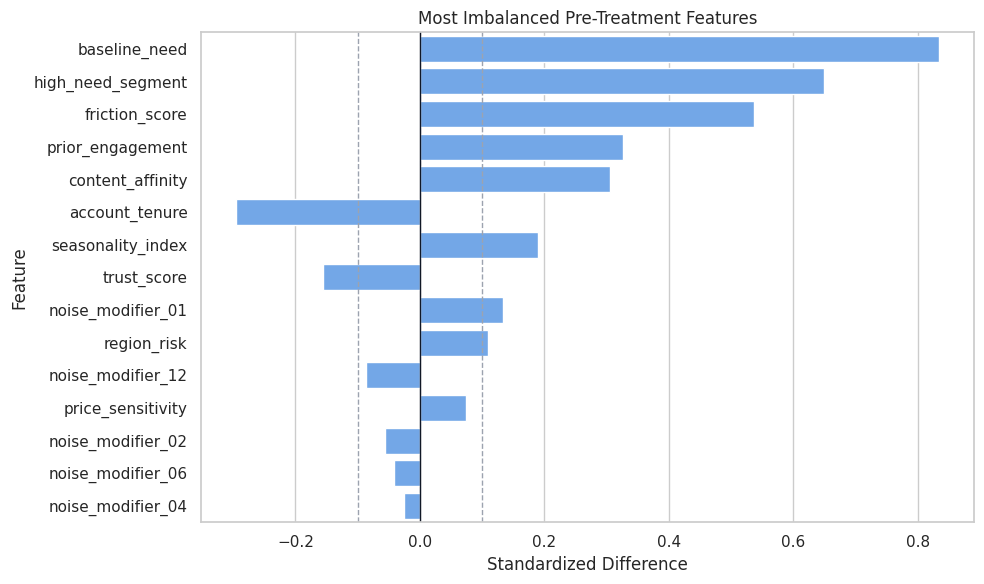

In [8]:
plot_balance = balance_table.head(15).copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plot_balance,
    x="standardized_difference",
    y="covariate",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.axvline(-0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Most Imbalanced Pre-Treatment Features")
ax.set_xlabel("Standardized Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment group is systematically different before treatment. The DML estimators should be judged against this context, not against a fictional randomized design.


### Propensity Overlap

Overlap checks whether treated and untreated rows exist across similar treatment-probability regions. Weak overlap makes treatment-effect estimation more extrapolative.

We know the true propensity in this simulation. In real data, we would estimate it.


In [9]:
propensity_summary = (
    teaching_df.assign(propensity_bucket=pd.cut(teaching_df["propensity"], bins=np.linspace(0, 1, 11), include_lowest=True))
    .groupby("propensity_bucket", observed=True)
    .agg(rows=("propensity", "size"), treatment_rate=("treatment", "mean"), true_cate_mean=("true_cate", "mean"))
    .reset_index()
)
propensity_summary["propensity_bucket"] = propensity_summary["propensity_bucket"].astype(str)
propensity_summary.to_csv(TABLE_DIR / "03_propensity_bucket_summary.csv", index=False)
display(propensity_summary)


,propensity_bucket,rows,treatment_rate,true_cate_mean
0,"(-0.001, 0.1]",157,0.0637,-0.0866
1,"(0.1, 0.2]",333,0.1622,0.0843
2,"(0.2, 0.3]",350,0.2343,0.2584
3,"(0.3, 0.4]",412,0.3325,0.2985
4,"(0.4, 0.5]",386,0.4715,0.3945
5,"(0.5, 0.6]",358,0.5140,0.5080
6,"(0.6, 0.7]",378,0.6323,0.5834
7,"(0.7, 0.8]",377,0.7454,0.7045
8,"(0.8, 0.9]",293,0.8396,0.9102
9,"(0.9, 1.0]",156,0.9295,1.0357


Most propensity buckets contain observed data, which is good for learning. The treatment rate rises with the propensity bucket, confirming that the assignment mechanism is not random.


#### Propensity Overlap Plot

The histogram gives a visual check of how much treated and untreated rows overlap in propensity space.


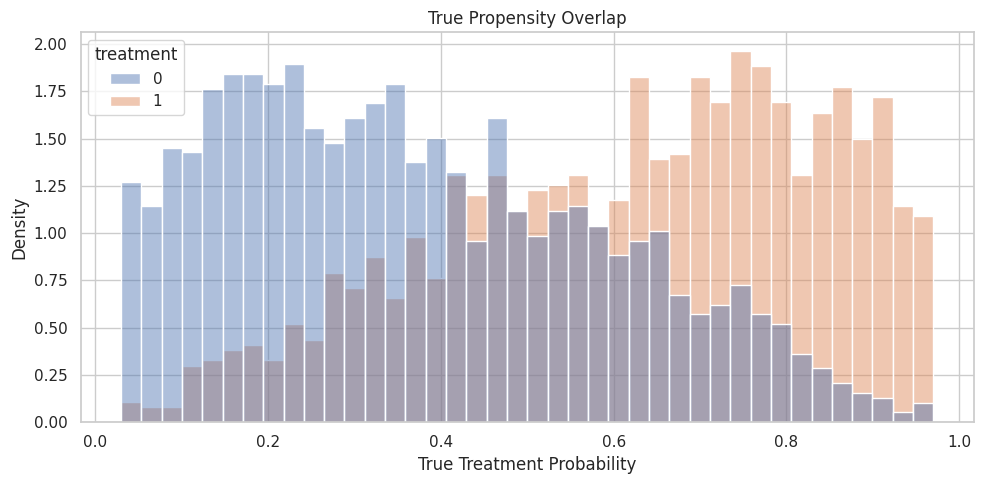

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("True Propensity Overlap")
ax.set_xlabel("True Treatment Probability")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


Overlap is imperfect but usable. That is a realistic teaching setting for DML: enough support to estimate effects, but enough confounding that naive comparisons are misleading.




#### X and W Roles

For these estimators:

- `X` is the feature set used in the final CATE model;
- `W` is the control set used for adjustment in nuisance models.

The same observed feature can sometimes be defensibly placed in either set. The key question is whether you want the reported treatment effect to vary along that feature.


In [11]:
role_table = pd.DataFrame(
    [
        {
            "feature": col,
            "econml_role": "X",
            "true_cate_driver": col in signal_modifier_cols,
            "reason": "Candidate effect modifier used by the final CATE model.",
        }
        for col in effect_modifier_cols
    ]
    + [
        {
            "feature": col,
            "econml_role": "W",
            "true_cate_driver": False,
            "reason": "Adjustment control used by nuisance models, not by the final CATE model.",
        }
        for col in control_cols
    ]
)
role_table.to_csv(TABLE_DIR / "03_x_w_role_table.csv", index=False)
display(role_table)


,feature,econml_role,true_cate_driver,reason
0,baseline_need,X,True,Candidate effect modifier used by the final CATE model.
1,prior_engagement,X,True,Candidate effect modifier used by the final CATE model.
2,friction_score,X,True,Candidate effect modifier used by the final CATE model.
3,price_sensitivity,X,True,Candidate effect modifier used by the final CATE model.
4,content_affinity,X,True,Candidate effect modifier used by the final CATE model.
5,region_risk,X,True,Candidate effect modifier used by the final CATE model.
6,high_need_segment,X,True,Candidate effect modifier used by the final CATE model.
7,trust_score,X,False,Candidate effect modifier used by the final CATE model.
8,recency_gap,X,False,Candidate effect modifier used by the final CATE model.
9,noise_modifier_01,X,False,Candidate effect modifier used by the final CATE model.


`SparseLinearDML` does not decide which variables are pre-treatment or causally admissible. It only regularizes among the `X` features we provide. The analyst still has to define a valid feature set.


#### Train and Test Split

The train set is used to fit nuisance models and CATE estimators. The test set is reserved for truth-known evaluation of CATE accuracy and ranking behavior.


In [12]:
train_idx, test_idx = train_test_split(
    teaching_df.index,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df["treatment"],
)
train_df = teaching_df.loc[train_idx].reset_index(drop=True)
test_df = teaching_df.loc[test_idx].reset_index(drop=True)
split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "treatment_rate": train_df["treatment"].mean(), "true_ate": train_df["true_cate"].mean()},
        {"split": "test", "rows": len(test_df), "treatment_rate": test_df["treatment"].mean(), "true_ate": test_df["true_cate"].mean()},
    ]
)
split_summary.to_csv(TABLE_DIR / "03_train_test_split_summary.csv", index=False)
display(split_summary)


,split,rows,treatment_rate,true_ate
0,train,2080,0.4875,0.4522
1,test,1120,0.4875,0.4783


The split preserves treatment balance and keeps the true ATE similar across train and test. That makes estimator comparisons easier to read.


#### Modeling Matrices

The code below prepares the arrays and data frames used by EconML. The most important modeling constraint is that oracle fields never enter `X`, `W`, or nuisance features.


In [13]:
Y_train = train_df["outcome"].to_numpy()
T_train = train_df["treatment"].to_numpy()
Y_test = test_df["outcome"].to_numpy()
T_test = test_df["treatment"].to_numpy()
X_train = train_df[effect_modifier_cols]
X_test = test_df[effect_modifier_cols]
W_train = train_df[control_cols]
W_test = test_df[control_cols]
nuisance_train = train_df[all_observed_covariates]
nuisance_test = test_df[all_observed_covariates]
true_cate_train = train_df["true_cate"].to_numpy()
true_cate_test = test_df["true_cate"].to_numpy()
matrix_summary = pd.DataFrame(
    [
        {"object": "Y_train", "rows": Y_train.shape[0], "columns": 1, "meaning": "Observed outcome."},
        {"object": "T_train", "rows": T_train.shape[0], "columns": 1, "meaning": "Observed binary treatment."},
        {"object": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1], "meaning": "Candidate effect modifiers."},
        {"object": "W_train", "rows": W_train.shape[0], "columns": W_train.shape[1], "meaning": "Controls for adjustment."},
        {"object": "nuisance_train", "rows": nuisance_train.shape[0], "columns": nuisance_train.shape[1], "meaning": "Observed pre-treatment features for separate nuisance diagnostics."},
    ]
)
matrix_summary.to_csv(TABLE_DIR / "03_model_matrix_summary.csv", index=False)
display(matrix_summary)


,object,rows,columns,meaning
0,Y_train,2080,1,Observed outcome.
1,T_train,2080,1,Observed binary treatment.
2,X_train,2080,21,Candidate effect modifiers.
3,W_train,2080,3,Controls for adjustment.
4,nuisance_train,2080,24,Observed pre-treatment features for separate nuisance diagnostics.


`X` is wider than the true CATE equation by design. That is what lets us see the difference between dense and sparse final-stage behavior.




### Separate Nuisance Diagnostics

EconML fits nuisance models internally, but separate out-of-fold diagnostics are helpful for learning. They show whether the observed covariates can predict outcome and treatment assignment before we call the causal estimator.


In [14]:
# Fit or evaluate the model objects used in the Separate Nuisance Diagnostics section.
outcome_probe = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
treatment_probe = RandomForestClassifier(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
outcome_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
treatment_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
Y_hat_oof = cross_val_predict(outcome_probe, nuisance_train, Y_train, cv=outcome_cv, method="predict")
T_hat_oof = cross_val_predict(treatment_probe, nuisance_train, T_train, cv=treatment_cv, method="predict_proba")[:, 1]
nuisance_diagnostics = pd.DataFrame(
    [
        {"nuisance_model": "outcome E[Y | X, W]", "metric": "out_of_fold_rmse", "value": np.sqrt(mean_squared_error(Y_train, Y_hat_oof))},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_auc", "value": roc_auc_score(T_train, T_hat_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_brier_score", "value": brier_score_loss(T_train, T_hat_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_log_loss", "value": log_loss(T_train, T_hat_oof)},
    ]
)
nuisance_diagnostics.to_csv(TABLE_DIR / "03_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)


,nuisance_model,metric,value
0,"outcome E[Y | X, W]",out_of_fold_rmse,1.1420
1,"treatment E[T | X, W]",out_of_fold_auc,0.7515
2,"treatment E[T | X, W]",out_of_fold_brier_score,0.2049
3,"treatment E[T | X, W]",out_of_fold_log_loss,0.5969


The treatment model can predict assignment better than chance, confirming confounding. The outcome model captures baseline response structure, which helps DML remove predictable outcome variation before estimating treatment effects.




#### Fit LinearDML

Now we fit `LinearDML` with random-forest nuisance models. The random forests are used for nuisance adjustment, while the final CATE model remains linear in `X`.

This distinction is important: flexible nuisance models do not make the final treatment-effect model nonlinear. They only help residualize treatment and outcome.


In [15]:
# Fit or evaluate the model objects used in the Fit LinearDML section.
if not ECONML_AVAILABLE:
    raise ImportError(f"EconML is not available in this environment: {ECONML_VERSION}")
linear_model_y = RandomForestRegressor(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
linear_model_t = RandomForestClassifier(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
linear_dml = LinearDML(
    model_y=linear_model_y,
    model_t=linear_model_t,
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
)
linear_dml.fit(Y_train, T_train, X=X_train, W=W_train, inference=None)
linear_cate_train = np.ravel(linear_dml.effect(X_train))
linear_cate_test = np.ravel(linear_dml.effect(X_test))
linear_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": linear_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": linear_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, linear_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, linear_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(linear_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)
linear_summary.to_csv(TABLE_DIR / "03_lineardml_summary.csv", index=False)
display(linear_summary)


,metric,value
0,test_estimated_ate,0.5203
1,test_true_ate,0.4783
2,test_ate_error,0.0420
3,test_cate_rmse,0.2477
4,test_cate_correlation,0.8824
5,test_cate_spearman,0.8760


`LinearDML` returns both an average effect over the test population and unit-level CATE estimates. The CATE correlation checks whether the model is recovering effect ranking, more than the mean.


#### Fit SparseLinearDML

`SparseLinearDML` uses the same `X` and `W` roles, but its final stage is regularized. This is useful when we include many candidate effect modifiers and expect only some of them to matter.

The sparse model complements causal design. It can shrink noisy CATE drivers, while post-treatment controls, omitted confounders, and poor overlap remain design problems.


In [16]:
# Fit or evaluate the model objects used in the Fit SparseLinearDML section.
sparse_model_y = RandomForestRegressor(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED + 1,
    n_jobs=-1,
)
sparse_model_t = RandomForestClassifier(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED + 1,
    n_jobs=-1,
)
sparse_dml = SparseLinearDML(
    model_y=sparse_model_y,
    model_t=sparse_model_t,
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
    n_alphas=40,
    n_alphas_cov=8,
    max_iter=4_000,
    n_jobs=-1,
)
sparse_dml.fit(Y_train, T_train, X=X_train, W=W_train, inference=None)
sparse_cate_train = np.ravel(sparse_dml.effect(X_train))
sparse_cate_test = np.ravel(sparse_dml.effect(X_test))
sparse_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": sparse_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": sparse_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, sparse_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, sparse_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(sparse_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)
sparse_summary.to_csv(TABLE_DIR / "03_sparselineardml_summary.csv", index=False)
display(sparse_summary)


,metric,value
0,test_estimated_ate,0.5271
1,test_true_ate,0.4783
2,test_ate_error,0.0488
3,test_cate_rmse,0.2501
4,test_cate_correlation,0.8816
5,test_cate_spearman,0.8744


`SparseLinearDML` produces the same kind of object as `LinearDML`: unit-level CATE estimates. The difference is in how the final-stage treatment-effect coefficients are regularized.




### Compare Estimator-Level Metrics

The next table compares raw observational difference, `LinearDML`, and `SparseLinearDML` against the known truth on the test population.


In [17]:
comparison_table = pd.DataFrame(
    [
        {
            "method": "raw treated-control difference",
            "estimated_ate_on_test_population": raw_difference,
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": raw_difference - true_cate_test.mean(),
            "cate_rmse": np.nan,
            "cate_correlation": np.nan,
            "cate_spearman": np.nan,
        },
        {
            "method": "LinearDML",
            "estimated_ate_on_test_population": linear_cate_test.mean(),
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": linear_cate_test.mean() - true_cate_test.mean(),
            "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, linear_cate_test)),
            "cate_correlation": np.corrcoef(true_cate_test, linear_cate_test)[0, 1],
            "cate_spearman": pd.Series(linear_cate_test).corr(pd.Series(true_cate_test), method="spearman"),
        },
        {
            "method": "SparseLinearDML",
            "estimated_ate_on_test_population": sparse_cate_test.mean(),
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": sparse_cate_test.mean() - true_cate_test.mean(),
            "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, sparse_cate_test)),
            "cate_correlation": np.corrcoef(true_cate_test, sparse_cate_test)[0, 1],
            "cate_spearman": pd.Series(sparse_cate_test).corr(pd.Series(true_cate_test), method="spearman"),
        },
    ]
)
comparison_table.to_csv(TABLE_DIR / "03_estimator_comparison.csv", index=False)
display(comparison_table)


,method,estimated_ate_on_test_population,true_ate_on_test_population,ate_error,cate_rmse,cate_correlation,cate_spearman
0,raw treated-control difference,1.0538,0.4783,0.5755,NaN,NaN,NaN
1,LinearDML,0.5203,0.4783,0.0420,0.2477,0.8824,0.8760
2,SparseLinearDML,0.5271,0.4783,0.0488,0.2501,0.8816,0.8744


DML estimators can be judged on both average-effect error and CATE recovery. The raw difference cannot be evaluated as a CATE model because it returns only one overall contrast.




#### Extract Final-Stage Coefficients

For both estimators, the final-stage coefficients describe treatment-effect heterogeneity. They are not baseline outcome coefficients and they are not propensity-model coefficients.

The next step combines the known true coefficients with the estimated coefficients from both estimators.


In [18]:
# Define reusable helpers for the Extract Final-Stage Coefficients section.
def extract_coef_table(estimator, estimator_name, feature_names):
    """
    Idea: Extract the coef table from a fitted object or result table so it can be reported consistently.
    
    Parameters
    ----------
    estimator : object
        Fitted causal estimator whose behavior is being inspected.
    estimator_name : object
        Readable label used in tables and plots.
    feature_names : list[str]
        Covariate or effect-modifier names shown in outputs.
    
    Returns
    -------
    pd.DataFrame
        Coefficient table with intercept and feature-level CATE terms.
    """
    intercept = float(np.ravel(estimator.intercept_)[0])
    coefs = np.ravel(estimator.coef_)
    if len(coefs) != len(feature_names):
        raise ValueError(f"{estimator_name} returned {len(coefs)} coefficients for {len(feature_names)} features")
    return pd.DataFrame(
        {
            "term": ["cate_intercept"] + feature_names,
            estimator_name: [intercept] + list(coefs),
        }
    )
linear_coef_table = extract_coef_table(linear_dml, "LinearDML", effect_modifier_cols)
sparse_coef_table = extract_coef_table(sparse_dml, "SparseLinearDML", effect_modifier_cols)
coef_comparison = (
    true_coef_table[["term", "true_cate_coefficient", "is_true_driver"]]
    .merge(linear_coef_table, on="term", how="left")
    .merge(sparse_coef_table, on="term", how="left")
)
coef_comparison["LinearDML_abs_error"] = (coef_comparison["LinearDML"] - coef_comparison["true_cate_coefficient"]).abs()
coef_comparison["SparseLinearDML_abs_error"] = (coef_comparison["SparseLinearDML"] - coef_comparison["true_cate_coefficient"]).abs()
coef_comparison["SparseLinearDML_practically_selected"] = coef_comparison["SparseLinearDML"].abs() >= 0.03
coef_comparison.to_csv(TABLE_DIR / "03_coefficient_comparison.csv", index=False)
display(coef_comparison)


,term,true_cate_coefficient,is_true_driver,LinearDML,SparseLinearDML,LinearDML_abs_error,SparseLinearDML_abs_error,SparseLinearDML_practically_selected
0,cate_intercept,0.4200,True,0.3577,0.3684,0.0623,0.0516,True
1,baseline_need,0.3000,True,0.0668,0.0645,0.2332,0.2355,True
2,prior_engagement,0.2200,True,0.1007,0.0985,0.1193,0.1215,True
3,friction_score,-0.2400,True,-0.2569,-0.2534,0.0169,0.0134,True
4,price_sensitivity,-0.1800,True,-0.1616,-0.1701,0.0184,0.0099,True
5,content_affinity,0.1600,True,0.1708,0.1684,0.0108,0.0084,True
6,region_risk,-0.1200,True,-0.0258,-0.0254,0.0942,0.0946,False
7,high_need_segment,0.2400,True,0.4970,0.4855,0.2570,0.2455,True
8,trust_score,0.0000,False,0.0248,0.0352,0.0248,0.0352,True
9,recency_gap,0.0000,False,-0.0430,-0.0391,0.0430,0.0391,True


Coefficient tables are where linear final-stage estimators shine. They turn CATE estimation into a readable statement about which features increase or decrease treatment benefit.


#### Coefficient Ranking

A wide coefficient table can still be hard to scan. The next step ranks candidate effect modifiers by absolute sparse coefficient and shows whether each one is a true CATE driver in the simulation.


In [19]:
ranked_coefficients = (
    coef_comparison.query("term != 'cate_intercept'")
    .assign(abs_sparse=lambda d: d["SparseLinearDML"].abs(), abs_linear=lambda d: d["LinearDML"].abs())
    .sort_values("abs_sparse", ascending=False)
    [["term", "is_true_driver", "true_cate_coefficient", "LinearDML", "SparseLinearDML", "abs_linear", "abs_sparse", "SparseLinearDML_practically_selected"]]
)
ranked_coefficients.to_csv(TABLE_DIR / "03_ranked_coefficients.csv", index=False)
display(ranked_coefficients.head(18))


,term,is_true_driver,true_cate_coefficient,LinearDML,SparseLinearDML,abs_linear,abs_sparse,SparseLinearDML_practically_selected
7,high_need_segment,True,0.2400,0.4970,0.4855,0.4970,0.4855,True
3,friction_score,True,-0.2400,-0.2569,-0.2534,0.2569,0.2534,True
4,price_sensitivity,True,-0.1800,-0.1616,-0.1701,0.1616,0.1701,True
5,content_affinity,True,0.1600,0.1708,0.1684,0.1708,0.1684,True
2,prior_engagement,True,0.2200,0.1007,0.0985,0.1007,0.0985,True
10,noise_modifier_01,False,0.0000,-0.0579,-0.0652,0.0579,0.0652,True
1,baseline_need,True,0.3000,0.0668,0.0645,0.0668,0.0645,True
9,recency_gap,False,0.0000,-0.0430,-0.0391,0.0430,0.0391,True
16,noise_modifier_07,False,0.0000,0.0337,0.0382,0.0337,0.0382,True
8,trust_score,False,0.0000,0.0248,0.0352,0.0248,0.0352,True


A sparse model is most useful when the top coefficients are mostly real effect drivers and the irrelevant modifiers are pushed toward small values. The exact threshold for practical selection is an analyst choice, not a universal law.





## Reporting and Takeaways

### Coefficient Concentration Summary

Instead of reading every coefficient, we can summarize how much absolute coefficient mass falls on true drivers versus noise features.


In [20]:
coef_mass_rows = []
for estimator_name in ["LinearDML", "SparseLinearDML"]:
    temp = coef_comparison.query("term != 'cate_intercept'").copy()
    temp["abs_coef"] = temp[estimator_name].abs()
    total_abs = temp["abs_coef"].sum()
    signal_abs = temp.loc[temp["is_true_driver"], "abs_coef"].sum()
    noise_abs = temp.loc[~temp["is_true_driver"], "abs_coef"].sum()
    coef_mass_rows.append(
        {
            "estimator": estimator_name,
            "total_abs_coefficient_mass": total_abs,
            "signal_abs_coefficient_mass": signal_abs,
            "noise_abs_coefficient_mass": noise_abs,
            "signal_share_of_abs_mass": signal_abs / total_abs,
            "noise_share_of_abs_mass": noise_abs / total_abs,
            "num_practical_nonzero_abs_ge_0_03": int((temp[estimator_name].abs() >= 0.03).sum()),
        }
    )
coef_mass_summary = pd.DataFrame(coef_mass_rows)
coef_mass_summary.to_csv(TABLE_DIR / "03_coefficient_mass_summary.csv", index=False)
display(coef_mass_summary)


,estimator,total_abs_coefficient_mass,signal_abs_coefficient_mass,noise_abs_coefficient_mass,signal_share_of_abs_mass,noise_share_of_abs_mass,num_practical_nonzero_abs_ge_0_03
0,LinearDML,1.6410,1.2796,0.3613,0.7798,0.2202,11
1,SparseLinearDML,1.6139,1.2658,0.3481,0.7843,0.2157,11


Sparse estimation is about more than individual coefficients. It is also about concentrating attention on a smaller part of the candidate modifier set.




### Coefficient Plot

The plot below compares true coefficients, dense `LinearDML` coefficients, and sparse `SparseLinearDML` coefficients for the most important terms. This makes sign recovery and shrinkage easier to see.


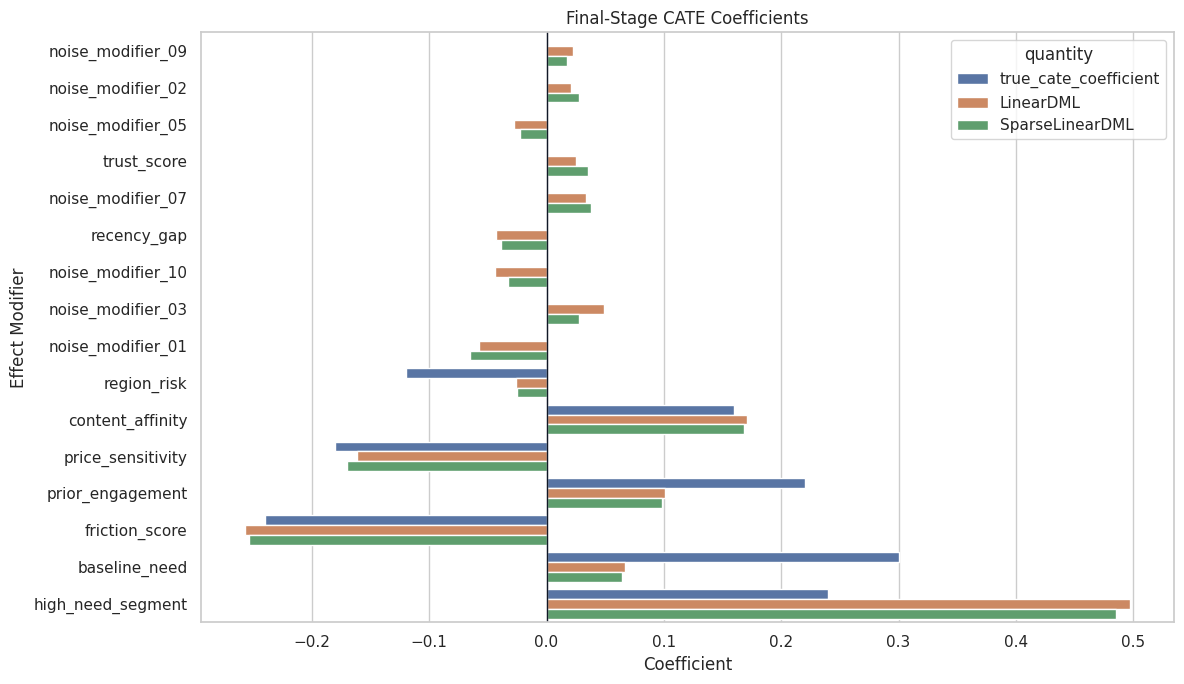

In [21]:
# Build and label the diagnostic visualization for the Coefficient Plot section.
plot_terms = (
    coef_comparison.query("term != 'cate_intercept'")
    .assign(max_abs=lambda d: d[["true_cate_coefficient", "LinearDML", "SparseLinearDML"]].abs().max(axis=1))
    .sort_values("max_abs", ascending=False)
    .head(16)["term"]
    .tolist()
)
coef_plot_df = coef_comparison[coef_comparison["term"].isin(plot_terms)].melt(
    id_vars=["term", "is_true_driver"],
    value_vars=["true_cate_coefficient", "LinearDML", "SparseLinearDML"],
    var_name="quantity",
    value_name="coefficient",
)
coef_plot_df["term"] = pd.Categorical(coef_plot_df["term"], categories=plot_terms[::-1], ordered=True)
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=coef_plot_df,
    x="coefficient",
    y="term",
    hue="quantity",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Final-Stage CATE Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Effect Modifier")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_cate_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()


Coefficient plots help communicate direction and relative size. They are most credible when paired with diagnostics about overlap, nuisance modeling, and robustness.




### CATE Recovery Scatter

Because this is simulated data, we can compare estimated CATE to true CATE on the test set. The dashed line is perfect recovery.


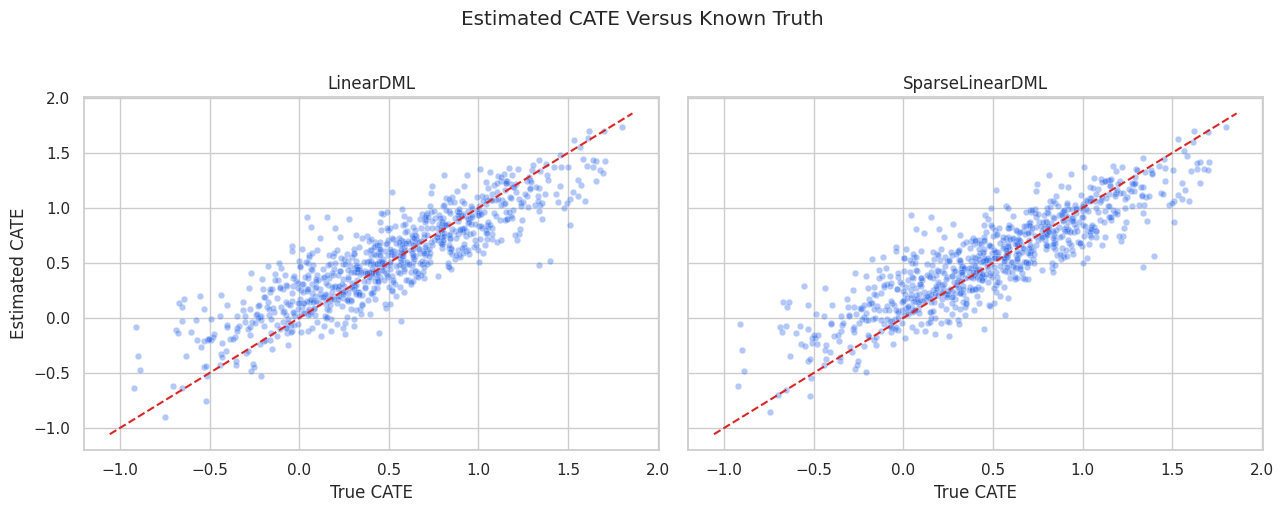

In [22]:
cate_plot_df = pd.concat(
    [
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": linear_cate_test, "estimator": "LinearDML"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": sparse_cate_test, "estimator": "SparseLinearDML"}),
    ],
    ignore_index=True,
)
limits = [
    min(cate_plot_df["true_cate"].min(), cate_plot_df["estimated_cate"].min()),
    max(cate_plot_df["true_cate"].max(), cate_plot_df["estimated_cate"].max()),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (estimator_name, estimator_df) in zip(axes, cate_plot_df.groupby("estimator")):
    sample_df = estimator_df.sample(n=min(850, len(estimator_df)), random_state=RANDOM_SEED)
    sns.scatterplot(data=sample_df, x="true_cate", y="estimated_cate", alpha=0.35, s=22, color="#2563eb", ax=ax)
    ax.plot(limits, limits, color="#dc2626", linestyle="--", linewidth=1.5)
    ax.set_title(estimator_name)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")
plt.suptitle("Estimated CATE Versus Known Truth", y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_cate_recovery_scatter.png", dpi=160, bbox_inches="tight")
plt.show()


Coefficient recovery and CATE recovery are related but not identical. A model can have imperfect coefficients yet still rank treatment effects reasonably well, and ranking quality is often what matters for targeting.


### Segment-Level CATE Recovery

Segment summaries translate unit-level CATE estimates into a form that is easier to communicate. Here we summarize by high-need segment and region risk.


In [23]:
test_results = test_df.assign(
    linear_cate=linear_cate_test,
    sparse_cate=sparse_cate_test,
)
segment_summary = (
    test_results.groupby(["high_need_segment", "region_risk"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        linear_cate=("linear_cate", "mean"),
        sparse_cate=("sparse_cate", "mean"),
        treatment_rate=("treatment", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)
segment_summary["linear_error"] = segment_summary["linear_cate"] - segment_summary["true_cate"]
segment_summary["sparse_error"] = segment_summary["sparse_cate"] - segment_summary["true_cate"]
segment_summary.to_csv(TABLE_DIR / "03_segment_cate_recovery.csv", index=False)
display(segment_summary)


,high_need_segment,region_risk,rows,true_cate,linear_cate,sparse_cate,treatment_rate,propensity_mean,linear_error,sparse_error
0,0,0,547,0.3719,0.4316,0.4414,0.3638,0.3820,0.0596,0.0694
1,0,1,240,0.2352,0.3832,0.3920,0.4542,0.4522,0.1480,0.1568
2,1,0,230,0.8535,0.7683,0.7688,0.6913,0.7115,-0.0853,-0.0847
3,1,1,103,0.7719,0.7573,0.7576,0.7670,0.7685,-0.0146,-0.0142


Segment summaries can reveal whether an estimator is useful for broad population comparisons. They also prevent us from relying only on an overall average effect.


### Segment Recovery Plot

This plot compares true and estimated segment-level CATE values. Each point is a segment average.


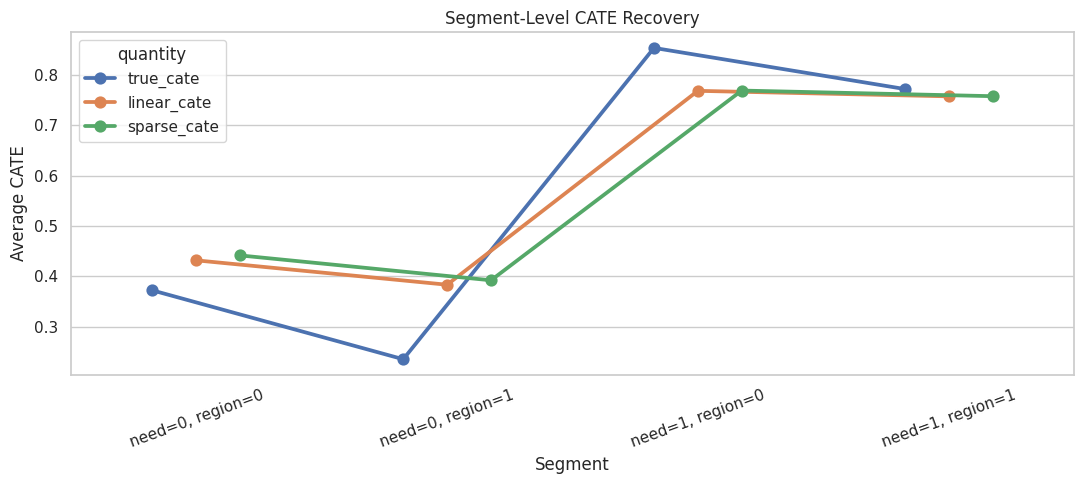

In [24]:
# Build and label the diagnostic visualization for the Segment Recovery Plot section.
segment_plot_df = segment_summary.melt(
    id_vars=["high_need_segment", "region_risk", "rows"],
    value_vars=["true_cate", "linear_cate", "sparse_cate"],
    var_name="quantity",
    value_name="average_cate",
)
segment_plot_df["segment"] = (
    "need=" + segment_plot_df["high_need_segment"].astype(str)
    + ", region=" + segment_plot_df["region_risk"].astype(str)
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.pointplot(
    data=segment_plot_df,
    x="segment",
    y="average_cate",
    hue="quantity",
    dodge=0.35,
    errorbar=None,
    ax=ax,
)
ax.set_title("Segment-Level CATE Recovery")
ax.set_xlabel("Segment")
ax.set_ylabel("Average CATE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_segment_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()


The sparse and dense estimators should tell a similar segment story if the main heterogeneity signals are stable. Large disagreements would be a reason to inspect features, overlap, and nuisance models more carefully.


#### CATE Decile Calibration

For treatment targeting, ranking is often as important as exact effect magnitude. The next table groups test rows by predicted CATE decile and compares estimated versus true average CATE.


In [25]:
calibration_frames = []
for estimator_name, score_col in [("LinearDML", "linear_cate"), ("SparseLinearDML", "sparse_cate")]:
    temp = test_results.copy()
    temp["cate_decile"] = pd.qcut(temp[score_col], q=10, labels=False, duplicates="drop") + 1
    deciles = (
        temp.groupby("cate_decile", observed=True)
        .agg(
            rows=("outcome", "size"),
            estimated_cate=(score_col, "mean"),
            true_cate=("true_cate", "mean"),
            treatment_rate=("treatment", "mean"),
            propensity_mean=("propensity", "mean"),
        )
        .reset_index()
    )
    deciles["estimator"] = estimator_name
    calibration_frames.append(deciles)
cate_decile_calibration = pd.concat(calibration_frames, ignore_index=True)
cate_decile_calibration.to_csv(TABLE_DIR / "03_cate_decile_calibration.csv", index=False)
display(cate_decile_calibration)


,cate_decile,rows,estimated_cate,true_cate,treatment_rate,propensity_mean,estimator
0,1,112,-0.2385,-0.3054,0.3929,0.4037,LinearDML
1,2,112,0.0659,-0.0072,0.4375,0.4236,LinearDML
2,3,112,0.2293,0.1674,0.4375,0.4559,LinearDML
3,4,112,0.3555,0.2813,0.4732,0.4811,LinearDML
4,5,112,0.4601,0.4179,0.4643,0.4829,LinearDML
5,6,112,0.5723,0.5229,0.4821,0.4986,LinearDML
6,7,112,0.6812,0.6638,0.4554,0.5234,LinearDML
7,8,112,0.8120,0.8018,0.5179,0.5499,LinearDML
8,9,112,0.9832,0.9582,0.6071,0.5784,LinearDML
9,10,112,1.2821,1.2825,0.6071,0.6048,LinearDML


A useful CATE model should produce higher true effects in higher predicted-effect deciles. In real data, we would need policy evaluation or experimental follow-up because true CATE would not be available.


#### CATE Decile Calibration Plot

The lines below show whether predicted CATE ranking is aligned with known true CATE ranking.


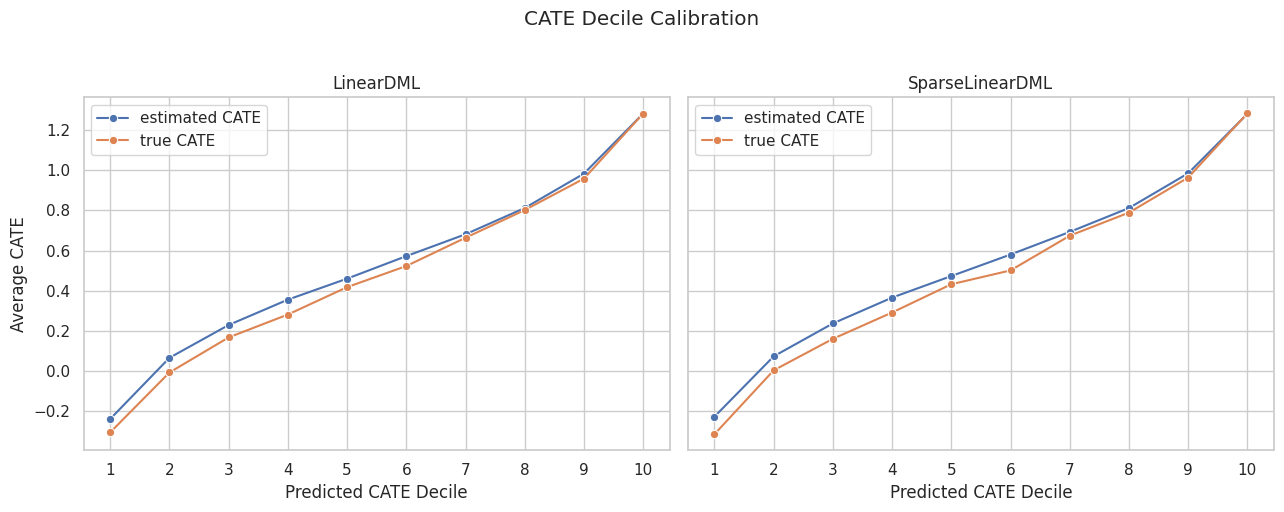

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (estimator_name, estimator_df) in zip(axes, cate_decile_calibration.groupby("estimator")):
    sns.lineplot(data=estimator_df, x="cate_decile", y="estimated_cate", marker="o", label="estimated CATE", ax=ax)
    sns.lineplot(data=estimator_df, x="cate_decile", y="true_cate", marker="o", label="true CATE", ax=ax)
    ax.set_title(estimator_name)
    ax.set_xlabel("Predicted CATE Decile")
    ax.set_ylabel("Average CATE")
    ax.set_xticks(sorted(estimator_df["cate_decile"].unique()))
plt.suptitle("CATE Decile Calibration", y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_cate_decile_calibration.png", dpi=160, bbox_inches="tight")
plt.show()


The decile view turns CATE estimation into a ranking check. Smoothly increasing true CATE across predicted deciles means the model is learning useful prioritization structure.


#### Simple Targeting Comparison

A common CATE use case is targeting the top fraction of units by estimated effect. The next step compares three rules on the test set:

- random 20% targeting;
- top 20% by `LinearDML` estimated CATE;
- top 20% by `SparseLinearDML` estimated CATE;
- oracle top 20% by true CATE, which is only available in simulation.


In [27]:
targeting_fraction = 0.20
k = int(np.ceil(targeting_fraction * len(test_results)))
random_selected = test_results.sample(n=k, random_state=RANDOM_SEED).index
linear_selected = test_results.sort_values("linear_cate", ascending=False).head(k).index
sparse_selected = test_results.sort_values("sparse_cate", ascending=False).head(k).index
oracle_selected = test_results.sort_values("true_cate", ascending=False).head(k).index
targeting_rows = []
for rule_name, selected_index in [
    ("random 20 percent", random_selected),
    ("top 20 percent by LinearDML", linear_selected),
    ("top 20 percent by SparseLinearDML", sparse_selected),
    ("oracle top 20 percent by true CATE", oracle_selected),
]:
    selected = test_results.loc[selected_index]
    targeting_rows.append(
        {
            "targeting_rule": rule_name,
            "selected_rows": len(selected),
            "average_true_cate_in_selected_group": selected["true_cate"].mean(),
            "share_high_need_segment": selected["high_need_segment"].mean(),
            "share_region_risk": selected["region_risk"].mean(),
            "average_propensity": selected["propensity"].mean(),
        }
    )
targeting_summary = pd.DataFrame(targeting_rows)
targeting_summary["gain_vs_random_true_cate"] = (
    targeting_summary["average_true_cate_in_selected_group"]
    - targeting_summary.loc[targeting_summary["targeting_rule"].eq("random 20 percent"), "average_true_cate_in_selected_group"].iloc[0]
)
targeting_summary.to_csv(TABLE_DIR / "03_targeting_summary.csv", index=False)
display(targeting_summary)


,targeting_rule,selected_rows,average_true_cate_in_selected_group,share_high_need_segment,share_region_risk,average_propensity,gain_vs_random_true_cate
0,random 20 percent,224,0.4847,0.2455,0.2545,0.4969,0.0000
1,top 20 percent by LinearDML,224,1.1203,0.5714,0.2634,0.5916,0.6356
2,top 20 percent by SparseLinearDML,224,1.1233,0.5714,0.2634,0.5952,0.6386
3,oracle top 20 percent by true CATE,224,1.2063,0.6339,0.2679,0.6903,0.7215


CATE models are often evaluated by how much better their targeted group is than random selection. The oracle row is an upper benchmark, not an achievable real-world policy.


#### Targeting Plot

The bar plot makes the targeting comparison easy to read: higher average true CATE in the selected group means the model is better at finding high-benefit units.


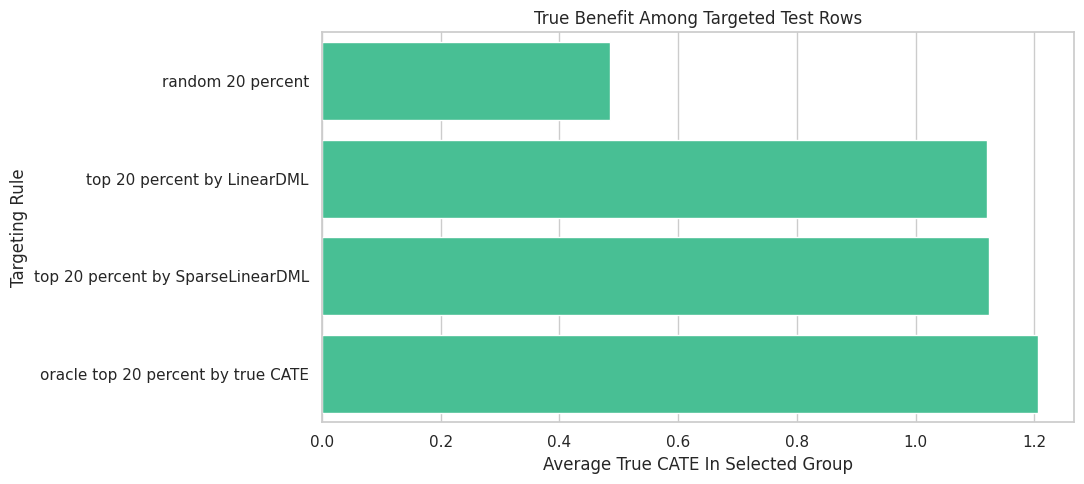

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=targeting_summary,
    x="average_true_cate_in_selected_group",
    y="targeting_rule",
    color="#34d399",
    ax=ax,
)
ax.set_title("True Benefit Among Targeted Test Rows")
ax.set_xlabel("Average True CATE In Selected Group")
ax.set_ylabel("Targeting Rule")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_targeting_summary.png", dpi=160, bbox_inches="tight")
plt.show()


Targeting is where CATE estimation becomes operational. Even when exact CATE values are noisy, a model can still be valuable if it ranks high-benefit units well.


#### Omitted Modifier Stress Test

A readable model can be too simple if it omits important effect modifiers from `X`. To make that risk concrete, the next step fits a restricted `LinearDML` that excludes two true CATE drivers from the final stage.

The omitted variables can still be included in `W` for adjustment, but the final CATE model is no longer allowed to vary along them.


In [29]:
# Fit or evaluate the model objects used in the Omitted Modifier Stress Test section.
restricted_x_cols = [
    "baseline_need",
    "prior_engagement",
    "price_sensitivity",
    "content_affinity",
    "region_risk",
    "high_need_segment",
]
restricted_w_cols = [col for col in all_observed_covariates if col not in restricted_x_cols]
restricted_linear_dml = LinearDML(
    model_y=RandomForestRegressor(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1),
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
)
restricted_linear_dml.fit(
    Y_train,
    T_train,
    X=train_df[restricted_x_cols],
    W=train_df[restricted_w_cols],
    inference=None,
)
restricted_cate_test = np.ravel(restricted_linear_dml.effect(test_df[restricted_x_cols]))
restricted_comparison = pd.DataFrame(
    [
        {
            "model": "LinearDML full X",
            "num_X_features": len(effect_modifier_cols),
            "test_cate_rmse": np.sqrt(mean_squared_error(true_cate_test, linear_cate_test)),
            "test_cate_spearman": pd.Series(linear_cate_test).corr(pd.Series(true_cate_test), method="spearman"),
            "test_ate_error": linear_cate_test.mean() - true_cate_test.mean(),
        },
        {
            "model": "LinearDML restricted X",
            "num_X_features": len(restricted_x_cols),
            "test_cate_rmse": np.sqrt(mean_squared_error(true_cate_test, restricted_cate_test)),
            "test_cate_spearman": pd.Series(restricted_cate_test).corr(pd.Series(true_cate_test), method="spearman"),
            "test_ate_error": restricted_cate_test.mean() - true_cate_test.mean(),
        },
    ]
)
restricted_comparison.to_csv(TABLE_DIR / "03_restricted_x_stress_test.csv", index=False)
display(restricted_comparison)


,model,num_X_features,test_cate_rmse,test_cate_spearman,test_ate_error
0,LinearDML full X,21,0.2477,0.8760,0.0420
1,LinearDML restricted X,6,0.2719,0.8488,0.0194


`X` controls what heterogeneity the final CATE model can express. Moving a true effect modifier out of `X` may still allow adjustment, but it prevents the reported effect from varying along that feature.




#### Practical Guidance Table

This table turns the lesson into a quick modeling guide for choosing between dense and sparse linear DML.


| situation | first estimator to try | reason |
| --- | --- | --- |
| Small number of carefully chosen effect modifiers | LinearDML | The final CATE coefficients are easy to read and unlikely to be cluttered. |
| Many candidate modifiers, only some expected to matter | SparseLinearDML | Regularization can shrink weaker CATE drivers and focus the coefficient table. |
| Strong nonlinear treatment-effect heterogeneity is expected | CausalForestDML or another flexible estimator | A linear final stage may be too restrictive even if nuisance models are flexible. |
| Primary goal is a transparent segment narrative | LinearDML plus segment summaries | Dense coefficients and segment-level checks are usually easier to explain. |
| Primary goal is treatment targeting | Compare LinearDML, SparseLinearDML, and flexible CATE models | Ranking quality matters; a more flexible model may rank better even if coefficients are less readable. |


There is no universally best estimator. `LinearDML` and `SparseLinearDML` are excellent first choices when a linear CATE story is plausible, but the modeling choice should follow the causal question and expected heterogeneity pattern.


#### Linear DML Checklist

Before presenting a `LinearDML` or `SparseLinearDML` result, it is worth checking the items below.


| check | why_it_matters |
| --- | --- |
| Treatment and outcome are clearly defined | The estimator needs a precise intervention and post-treatment response. |
| All X and W features are pre-treatment | Post-treatment controls can distort the causal estimand. |
| X contains the heterogeneity dimensions you want to report | The final CATE model can vary only along X. |
| W contains important adjustment controls | Nuisance models need enough information to reduce confounding. |
| Overlap is adequate | Unsupported regions force extrapolation. |
| Nuisance models have reasonable out-of-fold diagnostics | Poor nuisance models leave confounding in the residuals. |
| Coefficient signs match domain expectations where possible | Unexpected signs can flag leakage, coding errors, or misspecification. |
| Dense and sparse results are compared when X is wide | Sparse shrinkage helps reveal whether the coefficient story is stable. |
| CATE estimates are evaluated as rankings, point values and uncertainty | Treatment targeting depends heavily on ranking quality. |


Estimator output is only part of the work. A credible linear DML analysis also needs design checks, feature-role clarity, and sanity checks on the resulting CATE story.


## Summary

We have moved through how to use two readable EconML estimators for heterogeneous treatment effects.

The main takeaways are:

- `LinearDML` uses flexible nuisance models but keeps a linear final CATE model;
- `SparseLinearDML` is useful when the candidate `X` set is wide and only some modifiers are expected to matter;
- final-stage coefficients describe treatment-effect heterogeneity, not baseline outcome prediction;
- coefficient tables should be paired with overlap checks, nuisance diagnostics, and CATE recovery checks;
- sparse shrinkage can reduce coefficient clutter, but it can also shrink subtle real effects;
- CATE models should be evaluated both for average-effect accuracy and ranking usefulness;
- choosing `X` and `W` is a causal design decision, more than a modeling convenience.

The sequence next moves from linear final-stage models to `CausalForestDML`, where the CATE surface is allowed to be nonlinear and feature importance replaces simple coefficient reading.
